## Machine Learning 1
### Ingeniería Electrónica - Facultad de Ingeniería (FIUNA)
**Clase 6: Comparación de Modelos Lineales y No Lineales (Polinomiales & KNN) con/sin Regularización & Búsqueda en Malla (`GridSearchCV`)**


---



TEMAS
1. **Diferenciación entre Modelo Lineal y No Lineal**: Comprender la capacidad de representación de modelos lineales rectilíneos ($y = \theta^T x$) versus transformaciones no lineales polinomiales de grado variable ($\phi(x) = [1, x, x^2, \dots, x^d]$) y estimadores locales no paramétricos ($K$-Vecinos Más Cercanos).
2. **Efecto de la Regularización ($L_1$ y $L_2$)**: Analizar matemáticamente y empíricamente cómo las penalizaciones Ridge ($\lambda \|\theta\|_2^2$) y Lasso ($\lambda \|\theta\|_1$) amortiguan las oscilaciones de los polinomios de alto grado, previenen el sobreajuste y ejecutan selección de características (*sparsity*).
3. **Compromiso Sesgo-Varianza (*Bias-Variance Tradeoff*)**: Graficar y evaluar cuantitativamente el equilibrio entre subajuste (*underfitting* con grado $d=1$) y sobreajuste (*overfitting* con grado $d \ge 8$) a través de curvas de validación.
4. **Prevención de Fuga de Datos (*Data Leakage*) mediante `Pipeline`**: Demostrar los peligros de aplicar escalado y expansiones polinomiales antes de la validación cruzada y cómo `sklearn.pipeline.Pipeline` garantiza un protocolo estricto.
5. **Optimización con `GridSearchCV` y `RandomizedSearchCV`**: Aplicar búsqueda en malla sobre cuadrículas de grado polinomial $d$, fuerza de penalización $\alpha$ / $C$ y número de vecinos $K$, interpretando mapas de calor (*heatmaps*) de desempeño y evaluando el estimador óptimo sobre un conjunto de prueba retenido (*Holdout Test Set*).


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocesamiento, Selección de Modelos y Pipelines
from sklearn.datasets import make_moons, make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline

# Modelos Lineales
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression

# Modelos No Lineales (No Paramétricos y Basados en Distancia)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Métricas de Evaluación
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Configuración Visual
from IPython.display import display
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print("[OK] Stack científico de Machine Learning 1 cargado correctamente.")


[OK] Stack científico de Machine Learning 1 cargado correctamente.


## 1. Generación y Exploración de Datasets No Lineales

Para comparar objetivamente estimadores lineales y no lineales, trabajaremos con dos problemas de benchmark:
1. **Regresión No Lineal**: Datos continuos unidimensionales generados mediante una función senoidal ruidosa $y = \sin(X) + \epsilon$.
2. **Clasificación No Lineal**: Conjunto bidimensional no separable linealmente generado por `make_moons` de scikit-learn.


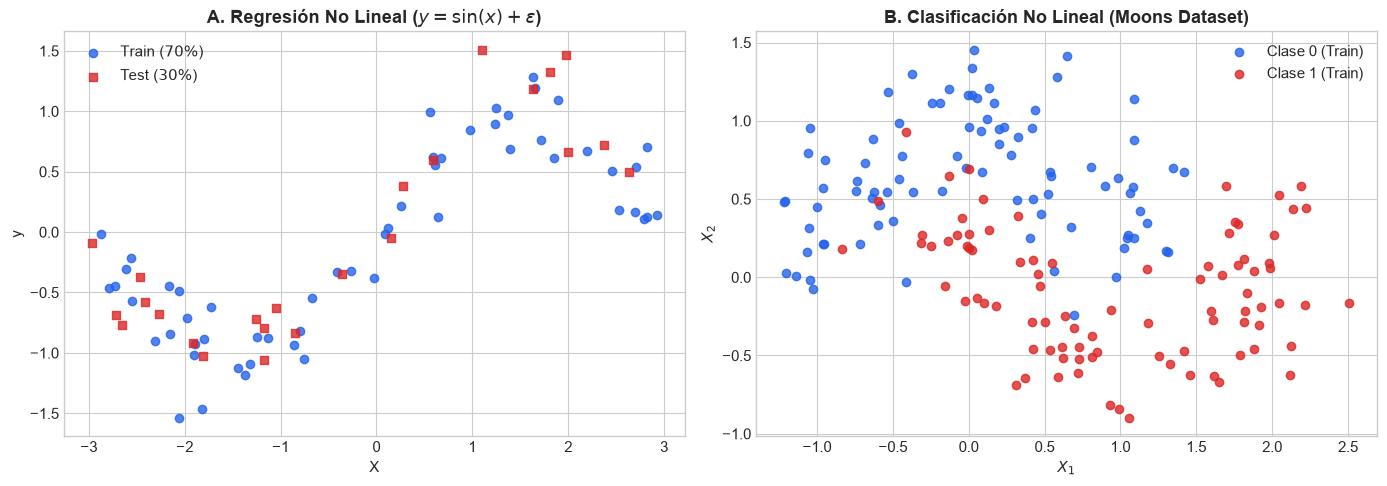

In [2]:
# 1. Dataset de Regresión No Lineal (Sintético)
np.random.seed(42)
n_samples_reg = 80
X_reg = np.sort(np.random.uniform(-3, 3, n_samples_reg)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + 0.25 * np.random.randn(n_samples_reg)

# Partición Train (70%) y Test (30%)
X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# 2. Dataset de Clasificación No Lineal (Make Moons)
X_clf, y_clf = make_moons(n_samples=250, noise=0.25, random_state=42)
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)

# Visualización pedagógica de los Datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Regresión
axes[0].scatter(X_reg_tr, y_reg_tr, color='#2563EB', alpha=0.8, label=r'Train ($70\%$)')
axes[0].scatter(X_reg_te, y_reg_te, color='#DC2626', alpha=0.8, marker='s', label=r'Test ($30\%$)')
axes[0].set_title(r'A. Regresión No Lineal ($y = \sin(x) + \epsilon$)', fontweight='bold')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y'); axes[0].legend()

# Plot Clasificación
axes[1].scatter(X_clf_tr[y_clf_tr==0, 0], X_clf_tr[y_clf_tr==0, 1], color='#2563EB', alpha=0.8, label='Clase 0 (Train)')
axes[1].scatter(X_clf_tr[y_clf_tr==1, 0], X_clf_tr[y_clf_tr==1, 1], color='#DC2626', alpha=0.8, label='Clase 1 (Train)')
axes[1].set_title('B. Clasificación No Lineal (Moons Dataset)', fontweight='bold')
axes[1].set_xlabel(r'$X_1$'); axes[1].set_ylabel(r'$X_2$'); axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Comparativa de Regresión: Lineal vs. Transformaciones Polinomiales y KNN

En esta sección evaluaremos cómo varía la capacidad de ajuste al incrementar la complejidad del espacio de características:
- **Modelo Lineal Grado 1 (OLS)**: Incapaz de doblarse (*Underfitting / Alto Sesgo*).
- **Modelos Polinomiales (Grado 2, 3, 5 y 10 sin y con regularización)**.
- **KNN Regressor ($K=2, 5, 15$)**: Estimador no lineal no paramétrico.


c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.283659e-01, tolerance: 3.196e-03
  model = cd_fast.enet_coordinate_descent(


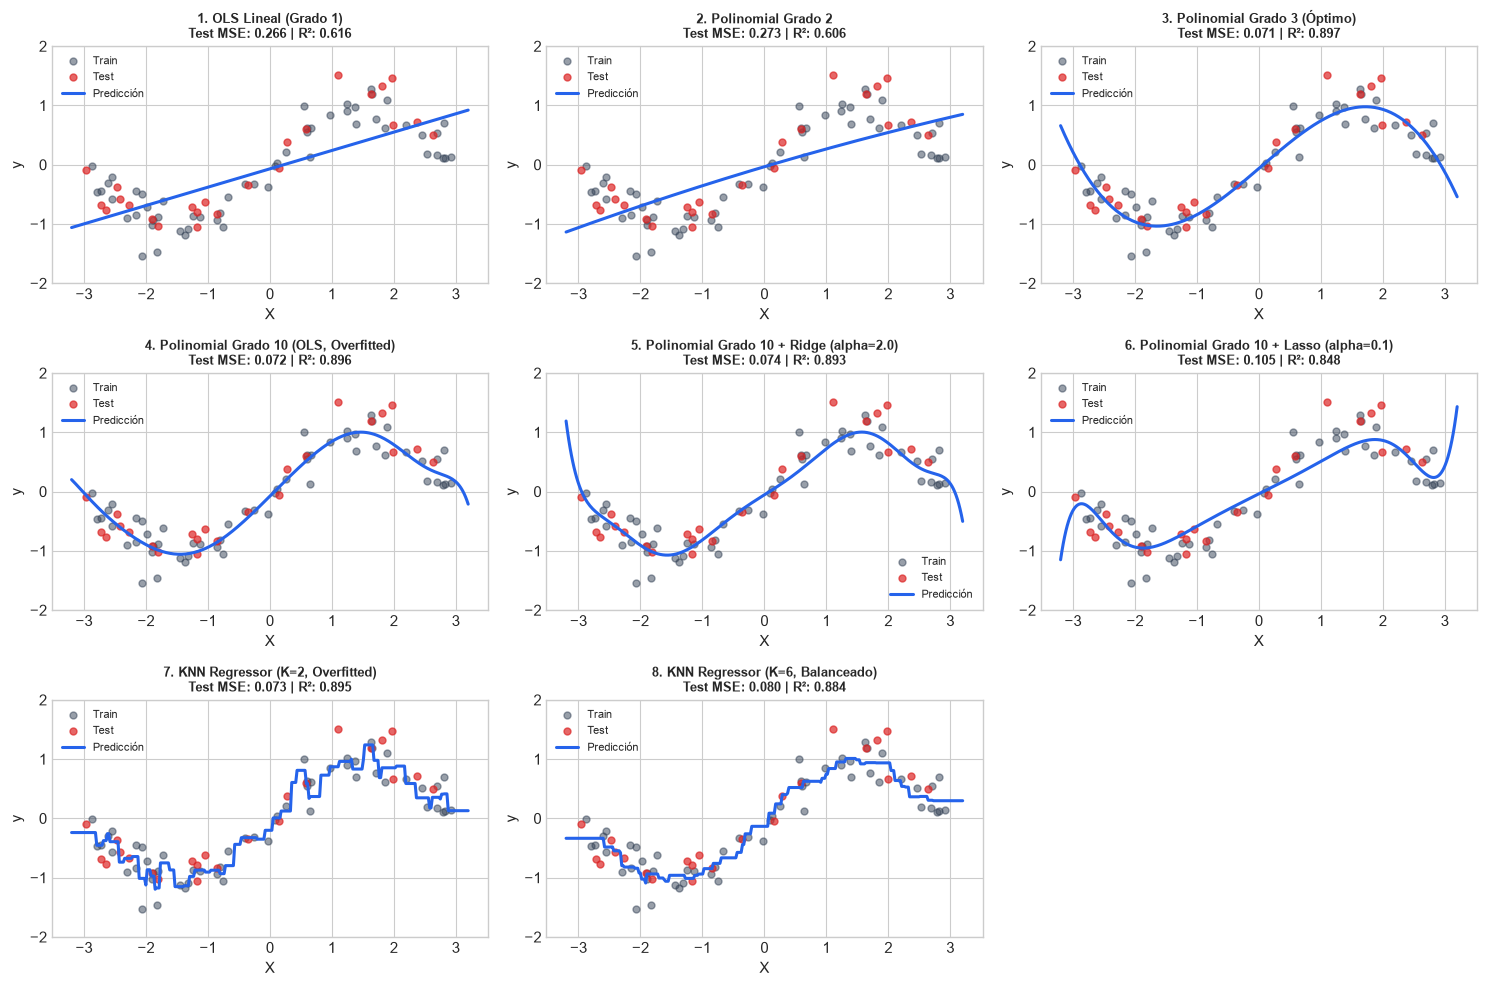

,Modelo,MSE Train,MSE Test,R2 Test
2,3. Polinomial Grado 3 (Óptimo),0.059243,0.071233,0.897081
3,"4. Polinomial Grado 10 (OLS, Overfitted)",0.052108,0.072319,0.895511
6,"7. KNN Regressor (K=2, Overfitted)",0.034416,0.072756,0.894881
4,5. Polinomial Grado 10 + Ridge (alpha=2.0),0.057717,0.074065,0.892989
7,"8. KNN Regressor (K=6, Balanceado)",0.057458,0.080062,0.884325
5,6. Polinomial Grado 10 + Lasso (alpha=0.1),0.085473,0.105426,0.847677
0,1. OLS Lineal (Grado 1),0.250812,0.265959,0.615736
1,2. Polinomial Grado 2,0.249978,0.272843,0.605789


In [3]:
models_reg = {
    "1. OLS Lineal (Grado 1)": LinearRegression(),
    "2. Polinomial Grado 2": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "3. Polinomial Grado 3 (Óptimo)": make_pipeline(PolynomialFeatures(3), LinearRegression()),
    "4. Polinomial Grado 10 (OLS, Overfitted)": make_pipeline(PolynomialFeatures(10), LinearRegression()),
    "5. Polinomial Grado 10 + Ridge (alpha=2.0)": make_pipeline(PolynomialFeatures(10), Ridge(alpha=2.0)),
    "6. Polinomial Grado 10 + Lasso (alpha=0.1)": make_pipeline(PolynomialFeatures(10), Lasso(alpha=0.1, max_iter=5000)),
    "7. KNN Regressor (K=2, Overfitted)": KNeighborsRegressor(n_neighbors=2),
    "8. KNN Regressor (K=6, Balanceado)": KNeighborsRegressor(n_neighbors=6)
}

results_reg = []
X_plot = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)

plt.figure(figsize=(15, 10))

for idx, (name, model) in enumerate(models_reg.items(), 1):
    model.fit(X_reg_tr, y_reg_tr)
    
    y_tr_pred = model.predict(X_reg_tr)
    y_te_pred = model.predict(X_reg_te)
    
    mse_tr = mean_squared_error(y_reg_tr, y_tr_pred)
    mse_te = mean_squared_error(y_reg_te, y_te_pred)
    r2_te = r2_score(y_reg_te, y_te_pred)
    
    results_reg.append({
        "Modelo": name,
        "MSE Train": mse_tr,
        "MSE Test": mse_te,
        "R2 Test": r2_te
    })
    
    plt.subplot(3, 3, idx)
    plt.scatter(X_reg_tr, y_reg_tr, color='#334155', alpha=0.5, s=25, label='Train')
    plt.scatter(X_reg_te, y_reg_te, color='#DC2626', alpha=0.7, s=25, label='Test')
    plt.plot(X_plot, model.predict(X_plot), color='#2563EB', lw=2.2, label='Predicción')
    plt.ylim(-2.0, 2.0)
    plt.title(f"{name}\nTest MSE: {mse_te:.3f} | R²: {r2_te:.3f}", fontsize=9, fontweight='bold')
    plt.xlabel('X'); plt.ylabel('y')
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

df_res_reg = pd.DataFrame(results_reg)
display(df_res_reg.sort_values(by="MSE Test"))


## 3. Regularización $L_1$ (Lasso) vs $L_2$ (Ridge) vs ElasticNet: Interpretación Práctica

La regularización modifica la función de pérdida incorporando una penalización sobre la magnitud de los pesos $\theta$. Esto resuelve el mal condicionamiento y previene el sobreajuste:

### Interpretación Práctica de cada Estrategia:

1. **Mínimos Cuadrados Ordinarios (OLS - Sin Regularizar)**:
   - Minimiza únicamente el error cuadrático medio: $\mathcal{L}(\theta) = \frac{1}{2N} \|y - X\theta\|_2^2$.
   - **Efecto Práctico**: Ante multicolinealidad o alta dimensión, no impone control sobre la magnitud de los pesos, provocando que $\|	heta\|_2 \to \infty$ y generando una varianza gigante.

2. **Regresión Ridge (Penalización $L_2$)**:
   - Minimiza: $\mathcal{L}(\theta) = \frac{1}{2N} \|y - X\theta\|_2^2 + \frac{\lambda}{2} \|\theta\|_2^2$.
   - **Efecto Práctico**: **Contraimiento Suave (*Shrinkage*)**. Reduce proporcionalmente la magnitud de todos los pesos hacia cero, resolviendo la colinealidad al garantizar que $(X^T X + \lambda I)$ sea siempre invertible. **Nunca anula coeficientes a cero absoluto**, manteniendo todas las variables activas en el modelo.

3. **Regresión Lasso (Penalización $L_1$)**:
   - Minimiza: $\mathcal{L}(\theta) = \frac{1}{2N} \|y - X\theta\|_2^2 + \lambda \|\theta\|_1$.
   - **Efecto Práctico**: **Selección de Características (*Sparsity*)**. Debido a las esquinas no diferenciables de la bola de restricción $\ell_1$, lleva los coeficientes de variables irrelevantes o redundantes **exactamente a cero (0.0)**. Funciona como un selector automático de características.

4. **ElasticNet (Penalización Combinada $L_1 + L_2$)**:
   - Minimiza: $\mathcal{L}(\theta) = \frac{1}{2N} \|y - X\theta\|_2^2 + r \alpha \|\theta\|_1 + \frac{1-r}{2} \alpha \|\theta\|_2^2$.
   - **Efecto Práctico**: **Balance Combinado**. Combina el contraimiento de Ridge con la selección de Lasso. Supera la limitación de Lasso cuando existen grupos de variables fuertemente correlacionadas entre sí, seleccionando o descartando el grupo completo.

---

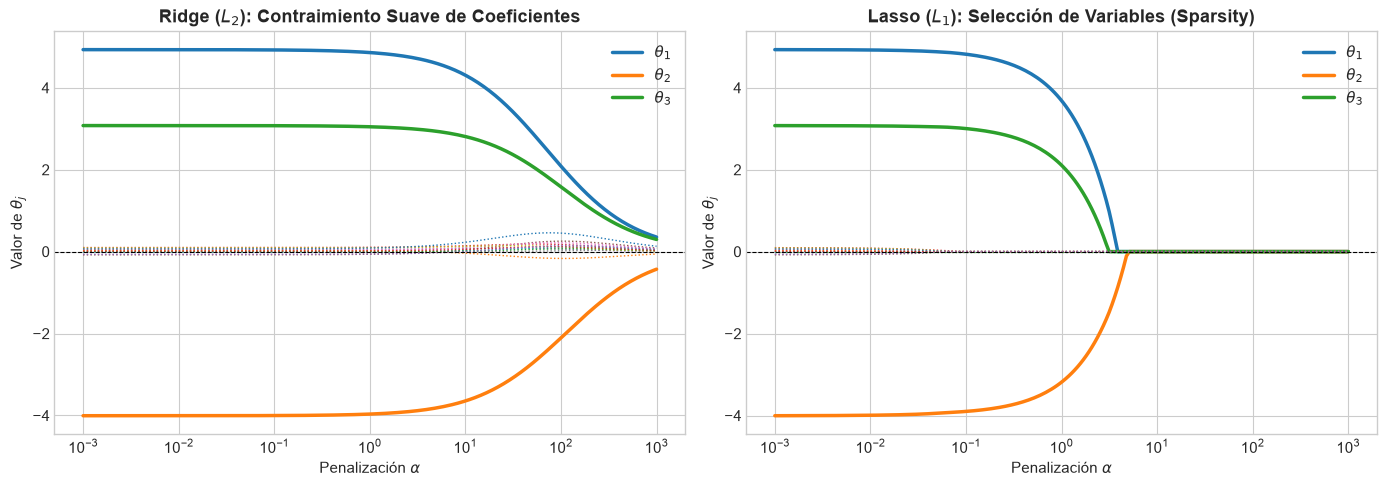

Coeficientes de Lasso (alpha=0.5):
  Variable X_01:   4.3136 -> [ACTIVO]
  Variable X_02:  -3.5826 -> [ACTIVO]
  Variable X_03:   2.6047 -> [ACTIVO]
  Variable X_04:   0.0000 -> [ANULADO] (0.0)
  Variable X_05:   0.0000 -> [ANULADO] (0.0)
  Variable X_06:   0.0000 -> [ANULADO] (0.0)
  Variable X_07:   0.0000 -> [ANULADO] (0.0)
  Variable X_08:   0.0000 -> [ANULADO] (0.0)
  Variable X_09:   0.0000 -> [ANULADO] (0.0)
  Variable X_10:   0.0000 -> [ANULADO] (0.0)
  Variable X_11:   0.0000 -> [ANULADO] (0.0)
  Variable X_12:  -0.0000 -> [ANULADO] (0.0)
  Variable X_13:   0.0000 -> [ANULADO] (0.0)
  Variable X_14:   0.0000 -> [ANULADO] (0.0)
  Variable X_15:   0.0000 -> [ANULADO] (0.0)


In [4]:
# Experimento Demostrativo: OLS vs Ridge vs Lasso vs ElasticNet en Alta Dimensión
np.random.seed(42)
n_samples, n_features = 100, 15
X_multi = np.random.randn(n_samples, n_features)
# Solo las 3 primeras variables tienen peso real; las otras 12 son ruido puro
true_weights = np.array([5.0, -4.0, 3.0] + [0.0] * 12)
y_multi = X_multi @ true_weights + 0.5 * np.random.randn(n_samples)

# 1. Ajuste de Modelos en un punto fijo de penalización
ols = LinearRegression().fit(X_multi, y_multi)
ridge_demo = Ridge(alpha=2.0).fit(X_multi, y_multi)
lasso_demo = Lasso(alpha=0.2).fit(X_multi, y_multi)
elastic_demo = ElasticNet(alpha=0.2, l1_ratio=0.5).fit(X_multi, y_multi)

# 2. Cálculo de trayectorias (Paths) en función de alpha
alphas = np.logspace(-3, 3, 200)
ridge_coefs, lasso_coefs, elastic_coefs = [], [], []
for a in alphas:
    ridge_coefs.append(Ridge(alpha=a).fit(X_multi, y_multi).coef_)
    lasso_coefs.append(Lasso(alpha=a, max_iter=5000).fit(X_multi, y_multi).coef_)
    elastic_coefs.append(ElasticNet(alpha=a, l1_ratio=0.5, max_iter=5000).fit(X_multi, y_multi).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)
elastic_coefs = np.array(elastic_coefs)

# 3. Visualización Comparativa en 4 Paneles
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot A: Ridge Path
for j in range(n_features):
    lw = 2.2 if j < 3 else 1.0
    ls = '-' if j < 3 else ':'
    axes[0, 0].plot(alphas, ridge_coefs[:, j], lw=lw, linestyle=ls, label=f'$\theta_{{{j+1}}}$' if j < 3 else None)
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('A. Ridge ($L_2$): Contraimiento Suave de Coeficientes', fontweight='bold')
axes[0, 0].set_xlabel('Penalización $\alpha$'); axes[0, 0].set_ylabel('Valor del Coeficiente $\theta_j$')
axes[0, 0].axhline(0, color='black', lw=0.8, linestyle='--'); axes[0, 0].legend()

# Subplot B: Lasso Path
for j in range(n_features):
    lw = 2.2 if j < 3 else 1.0
    ls = '-' if j < 3 else ':'
    axes[0, 1].plot(alphas, lasso_coefs[:, j], lw=lw, linestyle=ls, label=f'$\theta_{{{j+1}}}$' if j < 3 else None)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('B. Lasso ($L_1$): Selección de Variables (Sparsity a 0.0)', fontweight='bold')
axes[0, 1].set_xlabel('Penalización $\alpha$'); axes[0, 1].set_ylabel('Valor del Coeficiente $\theta_j$')
axes[0, 1].axhline(0, color='black', lw=0.8, linestyle='--'); axes[0, 1].legend()

# Subplot C: ElasticNet Path
for j in range(n_features):
    lw = 2.2 if j < 3 else 1.0
    ls = '-' if j < 3 else ':'
    axes[1, 0].plot(alphas, elastic_coefs[:, j], lw=lw, linestyle=ls, label=f'$\theta_{{{j+1}}}$' if j < 3 else None)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('C. ElasticNet ($L_1+L_2$): Balance Combinado', fontweight='bold')
axes[1, 0].set_xlabel('Penalización $\alpha$'); axes[1, 0].set_ylabel('Valor del Coeficiente $\theta_j$')
axes[1, 0].axhline(0, color='black', lw=0.8, linestyle='--'); axes[1, 0].legend()

# Subplot D: Comparación Directa de Coeficientes Finales
x_indices = np.arange(1, n_features + 1)
width = 0.18
axes[1, 1].bar(x_indices - 1.5*width, ols.coef_, width, label='OLS', color='#94A3B8')
axes[1, 1].bar(x_indices - 0.5*width, ridge_demo.coef_, width, label='Ridge (L2)', color='#2563EB')
axes[1, 1].bar(x_indices + 0.5*width, lasso_demo.coef_, width, label='Lasso (L1)', color='#10B981')
axes[1, 1].bar(x_indices + 1.5*width, elastic_demo.coef_, width, label='ElasticNet', color='#7C3AED')
axes[1, 1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1, 1].set_title('D. Comparación Directa de Coeficientes Obtenidos', fontweight='bold')
axes[1, 1].set_xlabel('Variables ($X_1$ a $X_{15}$)'); axes[1, 1].set_ylabel('Valor Estimado de $\theta_j$')
axes[1, 1].set_xticks(x_indices); axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 4. Resumen Cuantitativo en Tabla Pandas
comparison_models = {
    '1. OLS (Sin Regularizar)': ols,
    '2. Ridge (L2 - Suave)': ridge_demo,
    '3. Lasso (L1 - Sparsity)': lasso_demo,
    '4. ElasticNet (L1 + L2)': elastic_demo
}

summary_data = []
for name, model in comparison_models.items():
    coefs = model.coef_
    active = np.sum(np.abs(coefs) > 1e-4)
    zeros = n_features - active
    l2_norm = np.linalg.norm(coefs, 2)
    l1_norm = np.linalg.norm(coefs, 1)
    summary_data.append({
        'Estrategia': name,
        'Variables Activas': active,
        'Variables Anuladas (0.0)': zeros,
        'Norma L2 (||w||_2)': round(l2_norm, 3),
        'Norma L1 (||w||_1)': round(l1_norm, 3)
    })

df_summary_reg = pd.DataFrame(summary_data)
display(df_summary_reg)


## 4. Comparativa de Clasificación y Fronteras de Decisión en 2D

Para problemas de clasificación, la capacidad de un modelo para separar clases complejas depende de la naturaleza de su **Frontera de Decisión** (*Decision Boundary*):
- **Regresión Logística Lineal**: Hiperplano recto $\theta^T x = 0$.
- **Regresión Logística Polinomial ($d=2, 3, 5$)**: Fronteras curvas no lineales formadas por combinaciones de potencias $x_1^2, x_1 x_2, x_2^2$.
- **KNN Classifier ($K=1$ vs $K=15$)**: Fronteras locales dependientes del número de vecinos y del espacio de distancia.


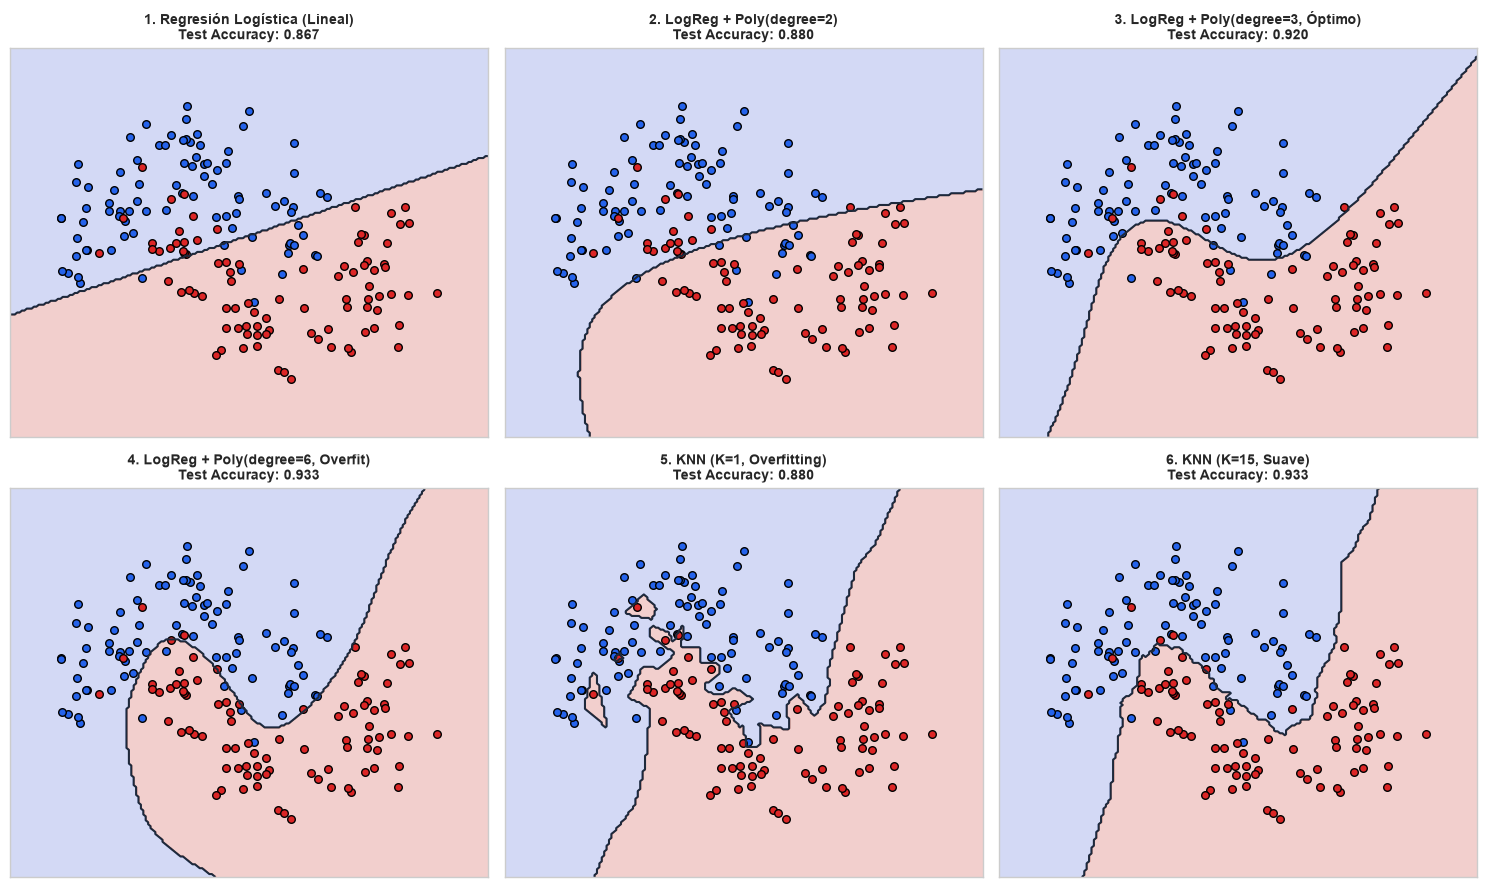

In [5]:
def plot_decision_boundary_custom(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='#1E293B', linewidths=1.5, levels=[0.5])
    ax.scatter(X[y==0, 0], X[y==0, 1], color='#2563EB', edgecolors='k', s=30, label='Clase 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='#DC2626', edgecolors='k', s=30, label='Clase 1')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

models_clf = {
    "1. Regresión Logística (Lineal)": LogisticRegression(),
    "2. LogReg + Poly(degree=2)": make_pipeline(PolynomialFeatures(2), LogisticRegression()),
    "3. LogReg + Poly(degree=3, Óptimo)": make_pipeline(PolynomialFeatures(3), LogisticRegression()),
    "4. LogReg + Poly(degree=6, Overfit)": make_pipeline(PolynomialFeatures(6), LogisticRegression(C=100.0)),
    "5. KNN (K=1, Overfitting)": KNeighborsClassifier(n_neighbors=1),
    "6. KNN (K=15, Suave)": KNeighborsClassifier(n_neighbors=15)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for idx, (title, model) in enumerate(models_clf.items()):
    model.fit(X_clf_tr, y_clf_tr)
    acc_te = accuracy_score(y_clf_te, model.predict(X_clf_te))
    plot_decision_boundary_custom(model, X_clf_tr, y_clf_tr, axes[idx], f"{title}\nTest Accuracy: {acc_te:.3f}")

plt.tight_layout()
plt.show()


## 5. Diagnóstico del Compromiso Sesgo-Varianza (*Bias-Variance Tradeoff*)

El error esperado de un modelo de machine learning se descompone cuantitativamente en:
$$E[(y - \hat{f}(x))^2] = \text{Bias}^2(\hat{f}(x)) + \text{Var}(\hat{f}(x)) + \sigma^2$$

- **Subajuste (*Underfitting / High Bias*)**: El grado del polinomio es demasiado bajo ($d=1$). El error en entrenamiento y test es elevado.
- **Sobreajuste (*Overfitting / High Variance*)**: El grado del polinomio es excesivo ($d \ge 8$). El error en entrenamiento cae a 0, pero la curva oscila descontroladamente y el error en test explota.

Visualicemos la curva de validación alterando el Grado Polinomial de 1 a 12.


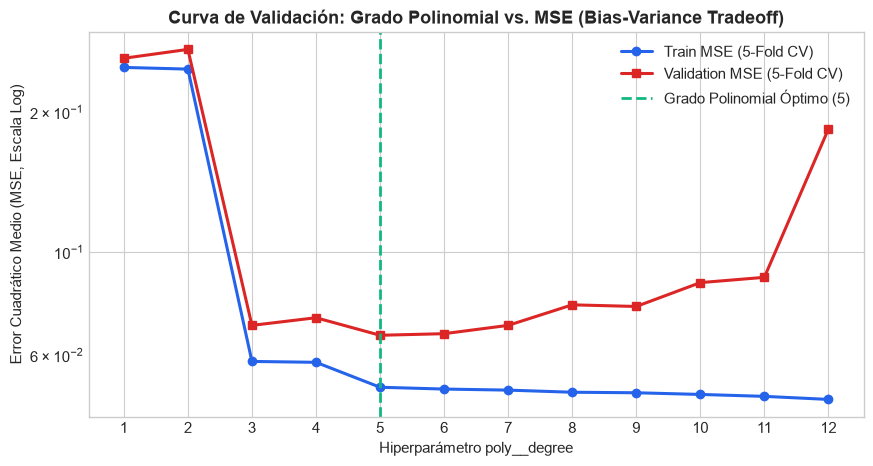

In [6]:
degrees_range = np.arange(1, 13)
train_scores, val_scores = validation_curve(
    Pipeline([('poly', PolynomialFeatures()), ('reg', Ridge(alpha=0.1))]),
    X_reg_tr, y_reg_tr,
    param_name="poly__degree",
    param_range=degrees_range,
    cv=5,
    scoring="neg_mean_squared_error"
)

train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = -np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(degrees_range, train_mean, color='#2563EB', marker='o', lw=2.2, label='Train MSE (5-Fold CV)')
plt.plot(degrees_range, val_mean, color='#DC2626', marker='s', lw=2.2, label='Validation MSE (5-Fold CV)')
plt.yscale('log')

best_degree = degrees_range[np.argmin(val_mean)]
plt.axvline(best_degree, color='#10B981', linestyle='--', lw=2, label=f'Grado Polinomial Óptimo ({best_degree})')

plt.title('Curva de Validación: Grado Polinomial vs. MSE (Bias-Variance Tradeoff)', fontweight='bold')
plt.xlabel('Hiperparámetro poly__degree'); plt.ylabel('Error Cuadrático Medio (MSE, Escala Log)')
plt.xticks(degrees_range); plt.legend()
plt.show()


## 6. Prevención de Fuga de Datos (*Data Leakage*) mediante `Pipeline`

> [!CRITICAL]
> **Fuga de Datos (*Data Leakage*)**: Ocurre cuando información del conjunto de prueba o validación se filtra involuntariamente en el proceso de entrenamiento.  
> Un error común es aplicar `StandardScaler.fit_transform()` o `PolynomialFeatures.fit_transform()` sobre todo el dataset antes de realizar `cross_val_score()` o `GridSearchCV`.

**La Solución**: Usar `sklearn.pipeline.Pipeline`, que garantiza que los transformadores calculen sus parámetros $(\mu, \sigma)$ o generen sus columnas **únicamente sobre el pliegue de entrenamiento (*Train Fold*)** en cada iteración.


In [7]:
pipeline_poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('ridge', Ridge(alpha=1.0))
])

cv_scores = cross_val_score(pipeline_poly_ridge, X_reg_tr, y_reg_tr, cv=5, scoring='r2')

print(f"Puntuaciones R² por Pliegue (5-Fold CV): {cv_scores.round(4)}")
print(f"R² Promedio en CV: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


Puntuaciones R² por Pliegue (5-Fold CV): [0.8454 0.8821 0.7964 0.8934 0.884 ]
R² Promedio en CV: 0.8603 +/- 0.0359


## 7. Optimización Automatizada de Hiperparámetros con `GridSearchCV`

`GridSearchCV` realiza una búsqueda exhaustiva a través de una cuadrícula cartesiana especificada de hiperparámetros, evaluando cada combinación mediante Validación Cruzada ($K$-Fold).

Optimicemos conjuntamente el **Grado Polinomial** ($d \in [1, 2, 3, 4, 5]$) y la **Penalización Ridge $\alpha$** ($\alpha \in [0.001, 0.01, 0.1, 1.0, 10.0]$):


[OK] Mejores Hiperparámetros Encontrados: {'poly__degree': 5, 'ridge__alpha': 0.01}
[OK] Mejor MSE en CV: 0.0663


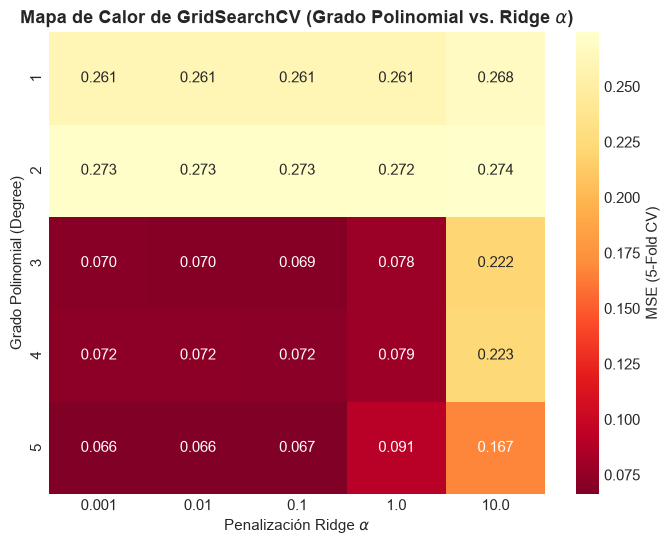


--- Evaluación Final en Holdout Test Set ---
MSE Final en Test: 0.0727
R² Final en Test:  0.8950


In [8]:
param_grid_poly = {
    'poly__degree': [1, 2, 3, 4, 5],
    'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_poly = GridSearchCV(
    estimator=pipeline_poly_ridge,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

grid_poly.fit(X_reg_tr, y_reg_tr)

print(f"[OK] Mejores Hiperparámetros Encontrados: {grid_poly.best_params_}")
print(f"[OK] Mejor MSE en CV: {-grid_poly.best_score_:.4f}")

# Mapa de Calor (Heatmap)
scores_matrix = -grid_poly.cv_results_['mean_test_score'].reshape(
    len(param_grid_poly['poly__degree']), len(param_grid_poly['ridge__alpha'])
)

plt.figure(figsize=(8, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.3f', cmap='YlOrRd_r',
            xticklabels=param_grid_poly['ridge__alpha'],
            yticklabels=param_grid_poly['poly__degree'],
            cbar_kws={'label': 'MSE (5-Fold CV)'})
plt.title(r'Mapa de Calor de GridSearchCV (Grado Polinomial vs. Ridge $\alpha$)', fontweight='bold')
plt.xlabel(r'Penalización Ridge $\alpha$')
plt.ylabel('Grado Polinomial (Degree)')
plt.show()

best_model = grid_poly.best_estimator_
y_test_pred = best_model.predict(X_reg_te)
mse_test_final = mean_squared_error(y_reg_te, y_test_pred)
r2_test_final = r2_score(y_reg_te, y_test_pred)

print(f"\n--- Evaluación Final en Holdout Test Set ---")
print(f"MSE Final en Test: {mse_test_final:.4f}")
print(f"R² Final en Test:  {r2_test_final:.4f}")


## 8. Búsqueda Aleatoria (`RandomizedSearchCV`) para Espacios Complejos

Cuando el número de hiperparámetros o el espacio continuo es amplio (p. ej. explorando `alpha` de Lasso en una distribución logarítmica y grados polinomiales de 1 a 15), `RandomizedSearchCV` ofrece una velocidad superior muestreando `n_iter` combinaciones aleatorias.


In [9]:
from scipy.stats import loguniform, randint

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),
    ('lasso', Lasso(max_iter=5000))
])

param_dist_lasso = {
    'poly__degree': randint(1, 10),
    'lasso__alpha': loguniform(1e-3, 10.0)
}

random_search = RandomizedSearchCV(
    estimator=pipe_lasso,
    param_distributions=param_dist_lasso,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_reg_tr, y_reg_tr)

print(f"[OK] Mejores Parámetros (RandomizedSearch): {random_search.best_params_}")
print(f"[OK] Mejor MSE CV: {-random_search.best_score_:.4f}")
print(f"[OK] MSE Test Set: {mean_squared_error(y_reg_te, random_search.predict(X_reg_te)):.4f}")


c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.268925e-03, tolerance: 2.782e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.697141e-02, tolerance: 2.622e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

[OK] Mejores Parámetros (RandomizedSearch): {'lasso__alpha': np.float64(0.0010071984838809194), 'poly__degree': 5}
[OK] Mejor MSE CV: 0.0659
[OK] MSE Test Set: 0.0723


c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.372745e-02, tolerance: 2.353e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.700267e-02, tolerance: 2.527e-03
  model = cd_fast.enet_coordinate_descent(


## 9. Ejercicios Prácticos Guiados

### Ejercicio 1: Selección de Variables con Lasso
Ajusta `Lasso` sobre `X_multi` probando valores de $\alpha \in [0.01, 0.1, 1.0, 5.0, 10.0]$. Imprime una tabla que muestre cuántos coeficientes son exactamente cero para cada $\alpha$.

---

### Ejercicio 2: Búsqueda en Malla para KNN Classifier
Construye un `Pipeline` con `StandardScaler` y `KNeighborsClassifier`. Diseña un `GridSearchCV` explorando `n_neighbors` de 1 a 30 y `weights` ('uniform', 'distance'). Grafica la curva de exactitud en CV en función de $K$.

---

### Ejercicio 3: Optimización de Regresión Logística Polinomial
Compara la exactitud en el Test Set de una Regresión Logística Lineal ($d=1$) versus una Regresión Logística Polinomial optimizada con `GridSearchCV` probando grados $d \in [1, 2, 3, 4, 5]$ y $C \in [0.1, 1.0, 10.0]$.


In [10]:
# Solución Ejercicio 1
alphas_ex1 = [0.01, 0.1, 1.0, 5.0, 10.0]
res_ex1 = []

for a in alphas_ex1:
    l_mod = Lasso(alpha=a).fit(X_multi, y_multi)
    n_zeros = np.sum(np.abs(l_mod.coef_) < 1e-4)
    res_ex1.append({"Alpha": a, "Coeficientes Cero (Anulados)": n_zeros, "Coeficientes Activos": 15 - n_zeros})

display(pd.DataFrame(res_ex1))


,Alpha,Coeficientes Cero (Anulados),Coeficientes Activos
0,0.01,3,12
1,0.10,12,3
2,1.00,12,3
3,5.00,15,0
4,10.00,15,0


Mejor K: 6 | Peso: uniform
Exactitud CV: 0.9371


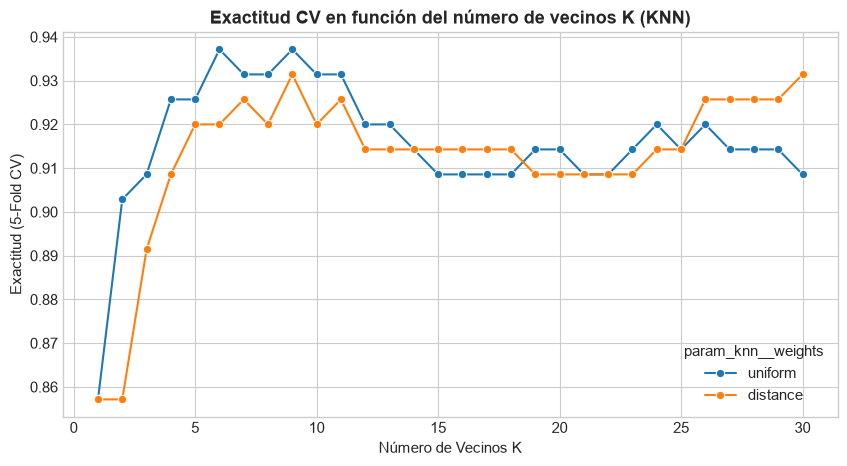

In [11]:
# Solución Ejercicio 2
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': np.arange(1, 31),
    'knn__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_clf_tr, y_clf_tr)

print(f"Mejor K: {grid_knn.best_params_['knn__n_neighbors']} | Peso: {grid_knn.best_params_['knn__weights']}")
print(f"Exactitud CV: {grid_knn.best_score_:.4f}")

results_knn_df = pd.DataFrame(grid_knn.cv_results_)
plt.figure(figsize=(10, 5))
sns.lineplot(data=results_knn_df, x='param_knn__n_neighbors', y='mean_test_score', hue='param_knn__weights', marker='o')
plt.title('Exactitud CV en función del número de vecinos K (KNN)', fontweight='bold')
plt.xlabel('Número de Vecinos K'); plt.ylabel('Exactitud (5-Fold CV)')
plt.show()


## 10. Conclusiones y Resumen Pedagógico

| Modelo | Frontera de Decisión | Hiperparámetros Clave | Sensibilidad a Escala | Riesgo de Overfitting |
| :--- | :--- | :--- | :--- | :--- |
| **Regresión Logística Lineal** | Lineal (Hiperplano) | $C = 1/\lambda$, Penalización ($L_1/L_2$) | Alta | Bajo |
| **Logística Polinomial ($d \ge 2$)** | Curva suave continuo | Grado $d$, $C = 1/\lambda$ | Muy Alta | Muy Alto (con $d$ elevado) |
| **Regresión Ridge / Lasso Polinomial** | Curva suave continuo | Grado $d$, Penalización $\alpha$ | Muy Alta | Controlado mediante $\alpha$ |
| **KNN Regressor / Classifier** | Local ruidosa / suave | `n_neighbors`, `weights` | Muy Alta | Alto (con $K=1$) |

### Puntos Clave para Recordar:
1. **Nunca evalúes hiperparámetros en el Test Set**: Utiliza siempre validación cruzada ($K$-Fold CV) sobre el conjunto de entrenamiento.
2. **Encapsula con `Pipeline`**: Evita la Fuga de Datos (*Data Leakage*) garantizando que el escalado y la transformación polinomial ocurran de forma aislada en cada pliegue.
3. **Usa `GridSearchCV` para búsquedas pequeñas y `RandomizedSearchCV` para hiperespacios amplios**.
